# Task 3: Prediction of perturbation effect

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scmlcourse.perturbation import *

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [ ]:
data_dir = Path("../../data")

### Data Loading


In [ ]:
data_module = DataModule(data_dir/"qced_data.h5ad", n_workers=4, n_top_genes=10)

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/ubuntu/scMLCourse/src/scmlcourse/perturbation.py:72: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self.adata.obs["perturbed_gene"] = self.adata.obs["perturbed_gene"].map(lambda x: "Ctrl" if pd.isna(x) else x)
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:43

['JAK1' 'IFNGR1' 'EMP1' 'BZW2' 'CD59' 'CHCHD2' 'APOD' 'CTSO' 'CTSB'
 'CSPG4'] CategoricalIndex(['control', 'ACTA2', 'B2M', 'A2M', 'AEBP1', 'CD274', 'CTSD',
                  'IFNGR2', 'CD44', 'FGFR1', 'CDH19', 'CD58', 'APOC2', 'APOE',
                  'ATP1B1', 'JAK2', 'C19orf48', 'AGA', 'CITED1', 'AHNAK',
                  'CDKN1A', 'FBXO32', 'FSTL3', 'HLA-DRB5', 'CD47', 'CCND2',
                  'FMN1', 'C6orf226', 'CMSS1', 'MFGE8', 'CD151', 'CDKN2B',
                  'HLA-A', 'CCR10', 'IDH2', 'CKS1B', 'GSN', 'CYP27A1', 'CTSA',
                  'JMJD7', 'CTSL'],
                 categories=['A2M', 'ACSL3', 'ACTA2', 'AEBP1', ..., 'WBP2', 'WNT7A', 'XAGE1A', 'control'], ordered=False, dtype='category', name='perturbed_gene')


## Simplistic Baseline: Small MLP

In [ ]:
from pytorch_lightning.loggers import CSVLogger
log_dir = Path("../logs")
log_dir.mkdir(exist_ok=True)

In [ ]:
mlp_config = dict(
    in_dim=data_module.n_vars,
    out_dim=data_module.n_vars,
    hidden_dims=(data_module.n_vars,),
)
model = Baseline(mlp_config, lr=0.001)


NameError: name 'data_module' is not defined

In [ ]:
import gc
gc.collect()

Seed set to 0
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ubuntu/scMLCourse/notebooks/logs exists and is not empty.
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not suppor

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0:   0%|          | 0/873 [00:00<?, ?it/s]                           

In [ ]:
logs = pd.read_csv(log_dir/"pert_regressor/version_3/metrics.csv")
logs

,epoch,lr-Adam,step,test_loss,test_pearson,train_loss_epoch,train_loss_step,train_pearson,val_loss,val_pearson
0,NaN,0.00001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,9,NaN,NaN,NaN,19.969610,NaN,NaN,NaN
2,0.0,NaN,19,NaN,NaN,NaN,15.035885,NaN,NaN,NaN
3,0.0,NaN,29,NaN,NaN,NaN,17.430710,NaN,NaN,NaN
4,0.0,NaN,39,NaN,NaN,NaN,19.991531,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1436,15.0,NaN,13909,NaN,NaN,NaN,23.509846,NaN,NaN,NaN
1437,15.0,NaN,13919,NaN,NaN,NaN,26.005491,NaN,NaN,NaN
1438,15.0,NaN,13919,NaN,NaN,NaN,NaN,NaN,20.526518,-0.015782
1439,15.0,NaN,13919,NaN,NaN,20.555359,NaN,-0.015375,NaN,NaN


<Axes: xlabel='epoch'>

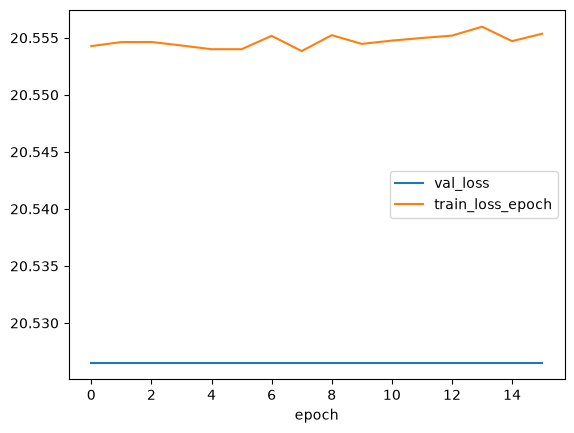

In [ ]:
logs.loc[~(logs["train_loss_epoch"].isna()&logs["val_loss"].isna())].groupby("epoch")[["val_loss", "train_loss_epoch"]].agg(lambda x: x[~x.isna()].iloc[0]).plot()

<Axes: xlabel='epoch'>

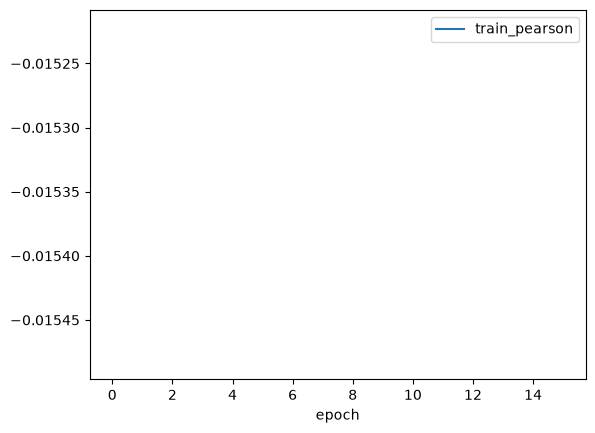

In [ ]:
logs.loc[~(logs["train_loss_epoch"].isna()&logs["val_loss"].isna())].plot("epoch", "train_pearson")